In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
df_ab_test = pd.read_csv('/content/drive/MyDrive/Data Analysis Showcase/3. Appendix Stimulated Projects/AB testing/AB testing_new check out flow.csv')
display(df_ab_test.head())

,user_id,group,age,country,sessions,avg_session_time_min,converted,revenue,churned
0,1,control,57,VN,1,7.7,0,0.0,1
1,2,treatment,24,TH,3,8.4,0,0.0,0
2,3,control,49,VN,5,1.8,0,0.0,0
3,4,control,36,VN,6,3.4,0,0.0,1
4,5,control,23,VN,8,10.3,0,0.0,0


## **1. Evaluating the primary success metrics: treatment effect on conversion**
*(The preliminary phase to qualify randomization has been conducted in the EDA file.)* <br> The primary purpose of the new checkout flow is to reduce purchase friction, so the first step is to evaluate its impact on conversion.<br>
* I use **`absolute conversion lift`** as the main decision metric, since it directly shows how many additional users convert under treatment compared with control. I also report **`Relative Risk (RR)`** as a supporting metric to describe the strength of the conversion effect on a proportional scale.
* The goal is not only to determine whether the treatment is directionally positive, but also whether the estimated gain is large enough to meet the business threshold for rollout.

In [ ]:
# create contigency table
contigen_df = pd.crosstab(index=df_ab_test['group'], columns= df_ab_test['converted'], margins=True)
contigen_df

converted,0,1,All
group,,,
control,4398,615,5013
treatment,4293,694,4987
All,8691,1309,10000


In [ ]:
# conversion lift and CI 95%

treatment_conv = (df_ab_test[df_ab_test['group'] == 'treatment']['converted']).mean()
control_conv = (df_ab_test[df_ab_test['group'] == 'control']['converted']).mean()
lift = treatment_conv - control_conv

se_lift = np.sqrt((treatment_conv * (1 - treatment_conv) / contigen_df.loc['treatment', 'All']) + (control_conv * (1 - control_conv) / contigen_df.loc['control', 'All']))
    # lift is a linear estimator and conversion is a binomial random variance that SE = np.sqrt(p(1-p)/n)
z_score = stats.norm.ppf(0.975) # confidence level 5% with 2-tailed distribution
lift_CI__lower = lift - z_score * se_lift
lift_CI_upper = lift + z_score * se_lift

print(f'Lift: {lift:.2%}\n')
print(f'CI 95% of lift: \nLower limit: {lift_CI__lower:.2%}\tUpper limit: {lift_CI_upper:.2%}')

Lift: 1.65%

CI 95% of lift: 
Lower limit: 0.33%	Upper limit: 2.97%


* From the perspective of absolute lift, the treatment group shows a positive increase in conversion, with a point estimate of **1.65%** and a **95% CI of [0.33%, 2.97%]**. Because the interval lies entirely above 0, the data are consistent with a positive treatment effect on conversion. This suggests that the new checkout flow may improve purchase completion.
* However, with the minimum detectable effect (MDE) threshold set at **2%**, the confidence interval still includes effect sizes below that threshold. This suggests that, while the treatment effect is directionally positive, its magnitude may still be insufficient to justify a full rollout.

In [ ]:
# relative risk and CI 95%

rrisk = stats.contingency.relative_risk(exposed_cases= contigen_df.loc['treatment', 1],
                                        exposed_total= contigen_df.loc['treatment', 'All'],
                                        control_cases= contigen_df.loc['control', 1],
                                        control_total= contigen_df.loc['control', 'All'])
print(f'Relative risk: {rrisk.relative_risk:.3f}')
print(f'\nCI 95% of relative risk: \nLower limit: {rrisk.confidence_interval(confidence_level=0.95).low:.3f}\tUpper limit: {rrisk.confidence_interval(confidence_level=0.95).high:.3f}')

Relative risk: 1.134

CI 95% of relative risk: 
Lower limit: 1.025	Upper limit: 1.255


* The estimated **`Relative Risk`** is **1.134**, with a **95% CI of [1.025, 1.255]**. Although this indicates a statistically meaningful improvement in conversion, the lower bound remains close to **1.0**, suggesting that the practical effect may be modest and not necessarily strong enough to justify immediate further investment.





> **Overall:**<br>
The observed data indicate a positive conversion effect in the treatment group, suggesting that the new checkout flow may help reduce purchase friction. However, from a business-effectiveness perspective, both the absolute lift and the relative risk intervals still include weaker-than-desired scenarios. As a result, the current evidence does not support a confident immediate full-scale rollout.



## **2. Trade-off within the target mechanism: average of basket size**
In this experiment, the new checkout flow is designed to reduce purchase friction, and its primary success criterion is therefore the conversion rate. But further, there is a requirement to examine whether that gain comes with an unintended trade-off in basket quality.<br> To assess this trade-off, I would evaluate 2 metrics:
* `Average revenue per buyer (ARPB)` is the direct metric that evaluate quality of average basket size from users who converted. It tells us whether the quality of purchases has changed.
* `Average revenue per user (ARPU)` is a generalized and aggregated metric reflecting the overall business outcome, as `ARPU = ARPB * conversion rate`. I would examine ARPU as a summary metric.



In [ ]:
df_treatment = df_ab_test[df_ab_test['group'] == 'treatment']
df_control = df_ab_test[df_ab_test['group'] == 'control']

In [ ]:
def bootstrap_mean_diff(x, y, Nboot=10000, seed=42):
  """
  Bootstrap for mean difference: mean(x) - mean(y)
  """
  rng = np.random.default_rng(seed)

  x_arr=np.asarray(x.dropna())
  y_arr=np.asarray(y.dropna())

  n_x = len(x_arr)
  n_y = len(y_arr)

  diff_means = np.zeros(Nboot)

  for i in range(Nboot):
    resamp_x = x_arr[rng.integers(low=0, high=n_x, size=n_x)]
    resamp_y = y_arr[rng.integers(low=0, high=n_y, size=n_y)]
    diff_means[i] = np.mean(resamp_x) - np.mean(resamp_y)

  return diff_means


In [ ]:
# bootstrap distribution for difference in mean ARPB

delta_buyer_bootstrap = bootstrap_mean_diff(x= df_treatment[df_treatment['converted'] == 1]['revenue'],
                                            y= df_control[df_control['converted'] == 1]['revenue'])

buyer_ci_low = np.percentile(delta_buyer_bootstrap, 2.5)
buyer_ci_high = np.percentile(delta_buyer_bootstrap, 97.5)
buyer_point_est = np.mean(delta_buyer_bootstrap)

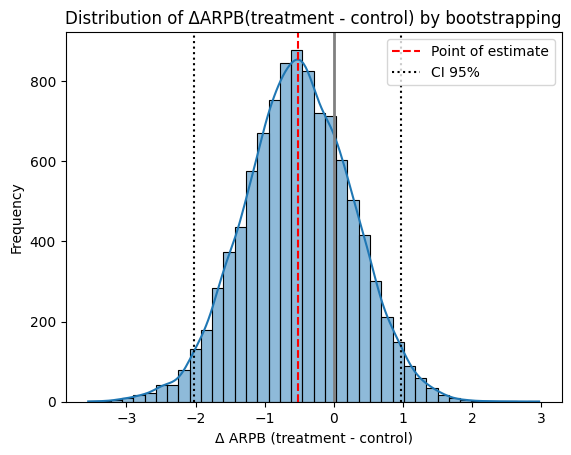

Point of estimate: -0.5165
CI 95%: [-2.0288, 0.9649]


In [ ]:
sns.histplot(delta_buyer_bootstrap, kde=True, bins=40)
plt.title('Distribution of ΔARPB(treatment - control) by bootstrapping')
plt.axvline(x=buyer_point_est, color='red', linestyle='--', label='Point of estimate')
plt.axvline(x=0, color='gray', linewidth=2)
plt.axvline(x=buyer_ci_low, color='black', linestyle=':')
plt.axvline(x=buyer_ci_high, color='black', linestyle=':', label= 'CI 95%')
plt.xlabel('Δ ARPB (treatment - control)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print(f'Point of estimate: {buyer_point_est:.4f}')
print(f'CI 95%: [{buyer_ci_low:.4f}, {buyer_ci_high:.4f}]')

In [ ]:
# construct bootstrapping for delta ARPU (treatment - control), then depict its distribution

delta_user_bootstrap = bootstrap_mean_diff(x= df_treatment['revenue'],
                                           y= df_control['revenue'])

user_ci_low = np.percentile(delta_user_bootstrap, 2.5)
user_ci_high = np.percentile(delta_user_bootstrap, 97.5)
user_point_est = np.mean(delta_user_bootstrap)

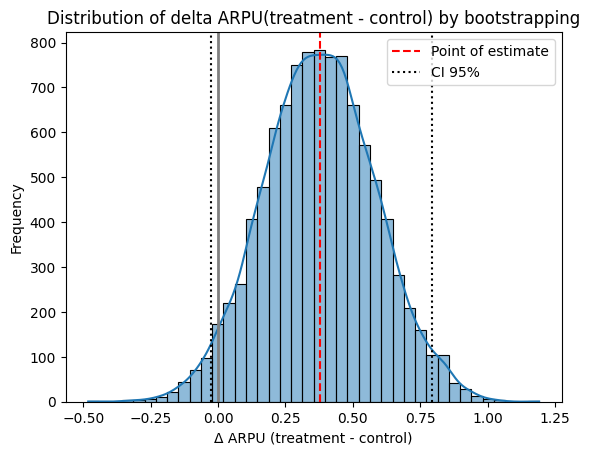

Point of estimate: 0.3775
CI 95%: [-0.0249, 0.7951]


In [ ]:
sns.histplot(delta_user_bootstrap, kde=True, bins=40)
plt.title('Distribution of delta ARPU(treatment - control) by bootstrapping')
plt.axvline(x=user_point_est, color='red', linestyle='--', label='Point of estimate')
plt.axvline(x=0, color='gray', linewidth=2)
plt.axvline(x=user_ci_low, color='black', linestyle=':', label='CI 95%')
plt.axvline(x=user_ci_high, color='black', linestyle=':')
plt.xlabel('Δ ARPU (treatment - control)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print(f'Point of estimate: {user_point_est:.4f}')
print(f'CI 95%: [{user_ci_low:.4f}, {user_ci_high:.4f}]')

* From the basket-quality perspective, the estimate point of Δ ARPB (treatment - control) is -0.5165 and CI 95% [-2.03,0.96]. This does not provide a clear evidence of a change in average basket value among buyers, although the interval still includes potentially negative scenarios.
* At the overall business level, the estimate point of Δ ARPU (treatment - control) is 0.3775, with a CI 95% [-0.02, 0.79]. Because the interval includes 0, the current data do not  support a confident conclusion that the new checkout flow improves revenue per user, despite the observed increase in conversion.<br>
>**Overall, after examing the trade-off, the current data show a positive signal on conversion, but the revenue impact remains too uncertain to justify deployment yet there is still room for potentially negative scenerios.**

## **3. Guardrail metrics: avoid degradating business health**
At this stage, I would define guardrail metrics to ensure that the experiment does not improve the primary metric at the expense of broader business health. In this checkout experiment, the key guardrail metrics are:
* **`Overall churn rate (treatment vs. control)`**: this serves as an early warning signal for whether the new checkout flow may introduce a negative downstream effect on user retention.
* **`Churn rate among buyers (treatment vs. control)`**: this is a diagnostic guardrail used to examine whether the additional converted users in the treatment group appear less durable or lower-quality than buyers in the control group.

In [ ]:
# Overall churn rate (treatment vs. control)

overall_churn_diff_bootstrap = bootstrap_mean_diff(x= df_treatment['churned'],
                                                   y= df_control['churned'])

overall_churn_ci_low = np.percentile(overall_churn_diff_bootstrap, 2.5)
overall_churn_ci_high = np.percentile(overall_churn_diff_bootstrap, 97.5)
overall_churn_point_est = np.mean(overall_churn_diff_bootstrap)

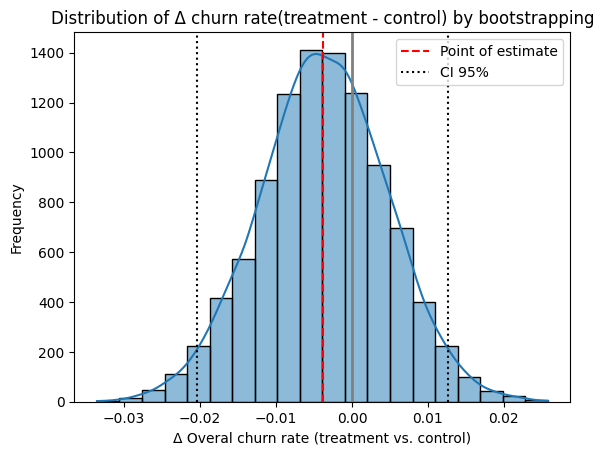

Point of estimate: -0.37%
CI 95%: [-2.04%, 1.26%]


In [ ]:
sns.histplot(overall_churn_diff_bootstrap, kde=True, bins=20)
plt.title('Distribution of Δ churn rate(treatment - control) by bootstrapping')
plt.axvline(x=overall_churn_point_est, color='red', linestyle='--', label='Point of estimate')
plt.axvline(x=0, color='gray', linewidth=2)
plt.axvline(x=overall_churn_ci_low, color='black', linestyle=':', label='CI 95%')
plt.axvline(x=overall_churn_ci_high, color='black', linestyle=':')
plt.xlabel('Δ Overal churn rate (treatment vs. control)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print(f'Point of estimate: {overall_churn_point_est:.2%}')
print(f'CI 95%: [{overall_churn_ci_low:.2%}, {overall_churn_ci_high:.2%}]')

In [ ]:
# Churn rate among buyers (treatment vs. control)

buyer_churn_diff_bootstrap = bootstrap_mean_diff(x= df_treatment[df_treatment['converted'] == 1]['churned'],
                                                   y= df_control[df_control['converted'] == 1]['churned'])

buyer_churn_ci_low = np.percentile(buyer_churn_diff_bootstrap, 2.5)
buyer_churn_ci_high = np.percentile(buyer_churn_diff_bootstrap, 97.5)
buyer_churn_point_est = np.mean(buyer_churn_diff_bootstrap)

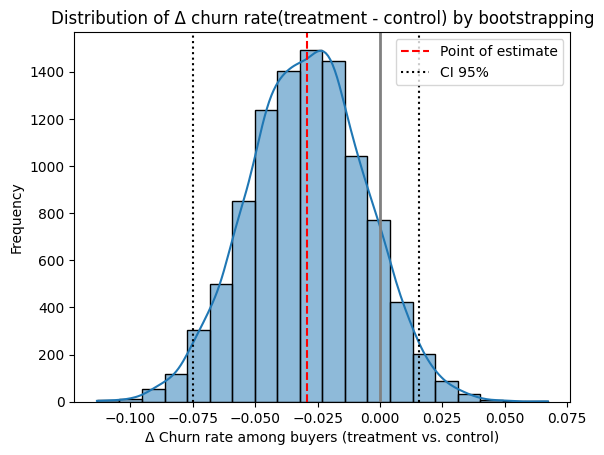

Point of estimate: -2.92%
CI 95%: [-7.50%, 1.57%]


In [ ]:
sns.histplot(buyer_churn_diff_bootstrap, kde=True, bins=20)
plt.title('Distribution of Δ churn rate(treatment - control) by bootstrapping')
plt.axvline(x=buyer_churn_point_est, color='red', linestyle='--', label='Point of estimate')
plt.axvline(x=0, color='gray', linewidth=2)
plt.axvline(x=buyer_churn_ci_low, color='black', linestyle=':', label='CI 95%')
plt.axvline(x=buyer_churn_ci_high, color='black', linestyle=':')
plt.xlabel('Δ Churn rate among buyers (treatment vs. control)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print(f'Point of estimate: {buyer_churn_point_est:.2%}')
print(f'CI 95%: [{buyer_churn_ci_low:.2%}, {buyer_churn_ci_high:.2%}]')

* The estimated `Δ overall churn rate` is **-0.37%**, with a **CI 95%: [-2.04%, 1.26%]**. Although the point estimate is favourable for treatment, the interval still includes small but adverse retention outcomes. As a result, the current data do not fully rule out downstream retention risk.
* At the buyer-level, `Δ churn rate among buyers` does not indicate a clear deterioration signal. However, the interval remains a modest increase in churn, suggesting that some degree of converted-user quality risk is still plausible.

## **4. Conclusion & Recommendation**

### **Conclusion**

* The new checkout flow shows a clear positive impact on conversion, with more users successfully completing a purchase compared to the current experience.
* However, the size of the improvement remains moderate and below the business threshold defined for a full-scale rollout, meaning the observed gain may not be large enough to justify deployment on its own.
* Importantly, the increase in purchases has not yet translated into a proven increase in revenue. While more users are converting, current results cannot confirm that they are spending more overall.
* On the risk side, there is no evidence that the treatment harms customer retention, but the data are not yet strong enough to completely rule out a small negative impact.<br>

**Overall, the experiment delivers a promising conversion signal, but the business value and long-term customer impact remain insufficiently validated for an immediate full rollout.**

### **Recommended next steps**

* Do not proceed with a full rollout yet; continue testing and data collection to reduce uncertainty around revenue impact.
* Extend the experiment to validate revenue impact with greater confidence.
* Investigate the behavior of high-session users to understand potential friction in the checkout journey (this recommendation is derived from Phase 1).
* Collect additional post-purchase and customer experience data to better understand churn drivers and long-term business impact.